# Prithvi EO V2 600M-TL Training and Segmentation

A lean, top-to-bottom workflow for temporal TFRecord loading, inspection,
Prithvi EO V2 600M-TL construction, local checkpoint loading, fine-tuning, evaluation,
and prediction visualization with an FCN decoder.

Update the paths and training options in the configuration cell before
running the notebook.

## Environment

This notebook uses a NumPy-1-compatible stack: TerraTorch 1.0,
TorchGeo 0.6.2, Rasterio 1.4.4, and Albumentations 1.4.6.

Run the next cell once when setting up the kernel. Restart the kernel after
installation, then continue from the imports cell. The imports cell also
selects Rasterio's bundled PROJ database to avoid mixed Conda/pip PROJ data.


In [ ]:
%pip install "numpy<2" "opencv-python==4.11.0.86" "opencv-python-headless==4.11.0.86" "albumentations==1.4.6" "terratorch==1.0" "torchgeo==0.6.2" "rasterio==1.4.4"


In [1]:
import importlib.util
import os
import random
import struct
from pathlib import Path

# Rasterio's wheel contains the PROJ database that matches its PROJ runtime.
_rasterio_spec = importlib.util.find_spec("rasterio")
if _rasterio_spec is not None:
    _proj_data = Path(_rasterio_spec.origin).parent / "proj_data"
    if _proj_data.exists():
        os.environ["PROJ_DATA"] = str(_proj_data)
        os.environ["PROJ_LIB"] = str(_proj_data)

import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

# Use TensorFlow only for TFRecord parsing; keep GPU memory for PyTorch.
try:
    tf.config.set_visible_devices([], "GPU")
    print("TensorFlow GPU disabled.")
except RuntimeError as error:
    print(
        "TensorFlow GPU was already initialized. "
        "Restart the kernel and run this cell before any TensorFlow work."
    )
    print(error)
    
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# Data and checkpoint paths
TRAIN_TFRECORD = Path(
    r"D:\Data\ssm_temporal\ssm_footprint_train_new.tfrecord"
)
VAL_TFRECORD = Path(
    r"D:\Data\ssm_temporal\ssm_footprint_no_cloud_val.tfrecord"
)  # Replace with a held-out validation file when available.
PRETRAINED_ENCODER_PATH = Path(
    r"Y:\SPOT\2023\Asare\Prithvi_models\Prithvi_EO_V2_600M_TL.pt"
)
FINETUNED_MODEL_PATH = Path("models/prithvi_600m_tl_fcn_best.pt")
OUTPUT_MODEL_PATH = FINETUNED_MODEL_PATH


# Data and model settings
TIMESTEPS = 4
IMAGE_SIZE = 224
IN_CHANNELS = 6
NUM_CLASSES = 3
TRAIN_BATCH_SIZE = 1
VAL_BATCH_SIZE = 1
NUM_WORKERS = 0


# Training settings
NUM_EPOCHS = 50
ENCODER_LEARNING_RATE = 3.0e-6
DECODER_LEARNING_RATE = 1.0e-4
WEIGHT_DECAY = 1.0e-2
ACCUMULATION_STEPS = 8
USE_MIXED_PRECISION = True
USE_GRADIENT_CHECKPOINTING = True
TRAIN_ENCODER = False  # Start decoder-only; set True to fine-tune all 600M parameters.
RUN_TRAINING = True
LOAD_PRETRAINED_ENCODER = True
LOAD_FINETUNED_MODEL = False


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("PROJ data:", os.environ.get("PROJ_DATA"))
for label, path in {
    "train data": TRAIN_TFRECORD,
    "validation data": VAL_TFRECORD,
    "600M-TL encoder": PRETRAINED_ENCODER_PATH,
    "fine-tuned model": FINETUNED_MODEL_PATH,
}.items():
    print(f"{label:20s}: {path} ({'found' if path.exists() else 'missing'})")

if TRAIN_TFRECORD == VAL_TFRECORD:
    print("Warning: training and validation currently use the same TFRecord.")


c:\Users\emmanuelasare\AppData\Local\anaconda3\envs\ml-env2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow GPU disabled.
Device: cuda
PROJ data: c:\Users\emmanuelasare\AppData\Local\anaconda3\envs\ml-env2\lib\site-packages\rasterio\proj_data
train data          : D:\Data\ssm_temporal\ssm_footprint_train_new.tfrecord (found)
validation data     : D:\Data\ssm_temporal\ssm_footprint_no_cloud_val.tfrecord (found)
600M-TL encoder     : Y:\SPOT\2023\Asare\Prithvi_models\Prithvi_EO_V2_600M_TL.pt (found)
fine-tuned model    : prithvi_600m_tl_fcn_best.pt (missing)


## Dataset

The dataset preserves zero-padded temporal frames, normalizes valid
frames only, and returns the temporal mask expected by the model.

In [2]:
def _center_pad_hw(array, target_hw):
    target_h, target_w = target_hw
    h, w = array.shape[:2]
    pad_h = max(target_h - h, 0)
    pad_w = max(target_w - w, 0)
    pad_top = pad_h // 2
    pad_left = pad_w // 2
    padding = [
        (pad_top, pad_h - pad_top),
        (pad_left, pad_w - pad_left),
    ]
    padding.extend([(0, 0)] * (array.ndim - 2))
    return np.pad(array, padding, mode="constant")


def _center_pad_cthw(image, target_hw):
    channels, timesteps, h, w = image.shape
    image_hwc = image.transpose(2, 3, 0, 1).reshape(h, w, channels * timesteps)
    image_hwc = _center_pad_hw(image_hwc, target_hw)
    padded_h, padded_w, _ = image_hwc.shape
    return image_hwc.transpose(2, 0, 1).reshape(
        channels, timesteps, padded_h, padded_w
    )


class MineFootprintTFRecordDataset(Dataset):
    MEAN = np.array(
        [1087.0, 1342.0, 1433.0, 2734.0, 1958.0, 1363.0],
        dtype=np.float32,
    )
    STD = np.array(
        [2248.0, 2179.0, 2178.0, 1850.0, 1242.0, 1049.0],
        dtype=np.float32,
    )

    FEATURE_DESCRIPTION = {
        "image_raw": tf.io.FixedLenFeature([], tf.string),
        "mask_raw": tf.io.FixedLenFeature([], tf.string),
        "height": tf.io.FixedLenFeature([], tf.int64),
        "width": tf.io.FixedLenFeature([], tf.int64),
        "channels": tf.io.FixedLenFeature([], tf.int64),
        "timesteps": tf.io.FixedLenFeature([], tf.int64),
        "temporal_coords": tf.io.VarLenFeature(tf.float32),
        "location_coords": tf.io.FixedLenFeature([2], tf.float32),
    }

    def __init__(self, tfrecord_path, transform=None, pad_to=(224, 224)):
        self.tfrecord_path = Path(tfrecord_path)
        if not self.tfrecord_path.exists():
            raise FileNotFoundError(
                f"TFRecord not found: {self.tfrecord_path}. "
                "Update the path in the configuration cell."
            )
        self.transform = transform
        self.pad_to = pad_to
        self._offsets = self._scan_index()
        self._file = self.tfrecord_path.open("rb")

    def _scan_index(self):
        offsets = []
        with self.tfrecord_path.open("rb") as file:
            position = 0
            while True:
                header = file.read(12)
                if not header:
                    break
                record_length = struct.unpack("<Q", header[:8])[0]
                offsets.append(position)
                position += 12 + record_length + 4
                file.seek(position)
        return offsets

    def _read_record(self, offset):
        self._file.seek(offset)
        header = self._file.read(12)
        record_length = struct.unpack("<Q", header[:8])[0]
        data = self._file.read(record_length)
        self._file.read(4)
        return data

    def __len__(self):
        return len(self._offsets)

    def _normalize_valid_frames(self, image, temporal_mask):
        channels = image.shape[0]
        valid = temporal_mask.astype(bool)
        normalized = np.zeros_like(image, dtype=np.float32)

        if not valid.any():
            return normalized

        if channels == len(self.MEAN):
            mean = self.MEAN.reshape(channels, 1, 1, 1)
            std = (self.STD + 1e-6).reshape(channels, 1, 1, 1)
        else:
            real = image[:, valid]
            mean = real.mean(axis=(1, 2, 3), keepdims=True)
            std = real.std(axis=(1, 2, 3), keepdims=True) + 1e-6

        normalized[:, valid] = (image[:, valid] - mean) / std
        return normalized

    def _apply_transform(self, image, mask):
        channels, timesteps, h, w = image.shape
        image_hwc = image.transpose(2, 3, 0, 1).reshape(
            h, w, channels * timesteps
        )
        augmented = self.transform(image=image_hwc, mask=mask)
        image_hwc = np.asarray(augmented["image"])
        mask = np.asarray(augmented["mask"])
        new_h, new_w, _ = image_hwc.shape
        image = image_hwc.transpose(2, 0, 1).reshape(
            channels, timesteps, new_h, new_w
        )
        return image, mask

    def __getitem__(self, index):
        serialized = self._read_record(self._offsets[index])
        example = tf.io.parse_single_example(
            serialized, self.FEATURE_DESCRIPTION
        )

        h = int(example["height"])
        w = int(example["width"])
        channels = int(example["channels"])
        timesteps = int(example["timesteps"])

        image = np.frombuffer(
            example["image_raw"].numpy(), dtype=np.float32
        ).reshape(channels, timesteps, h, w)
        mask = np.frombuffer(
            example["mask_raw"].numpy(), dtype=np.uint8
        ).reshape(h, w)

        image = np.nan_to_num(image, nan=0.0)
        mask = np.nan_to_num(mask, nan=0).astype(np.uint8)
        temporal_mask = (
            np.abs(image).sum(axis=(0, 2, 3)) > 0
        ).astype(np.float32)

        image = self._normalize_valid_frames(image, temporal_mask)
        image = _center_pad_cthw(image, self.pad_to)
        mask = _center_pad_hw(mask, self.pad_to)

        temporal_coords = tf.sparse.to_dense(
            example["temporal_coords"]
        ).numpy().astype(np.float32).reshape(timesteps, 2)
        location_coords = (
            example["location_coords"].numpy().astype(np.float32)
        )

        if self.transform is not None:
            image, mask = self._apply_transform(image, mask)

        return {
            "image": torch.from_numpy(
                np.ascontiguousarray(image)
            ).float(),
            "temporal_coords": torch.from_numpy(
                np.ascontiguousarray(temporal_coords)
            ).float(),
            "location_coords": torch.from_numpy(
                np.ascontiguousarray(location_coords)
            ).float(),
            "temporal_mask": torch.from_numpy(
                np.ascontiguousarray(temporal_mask)
            ).float(),
            "mask": torch.from_numpy(
                np.ascontiguousarray(mask)
            ).long(),
        }

    def close(self):
        if hasattr(self, "_file") and not self._file.closed:
            self._file.close()

    def __del__(self):
        try:
            self.close()
        except Exception:
            pass


def make_temporal_collate(timesteps=4, random_length=False):
    def collate(samples):
        images = []
        temporal_coords = []
        location_coords = []
        temporal_masks = []
        masks = []

        for sample in samples:
            image = torch.as_tensor(sample["image"])
            coords = torch.as_tensor(sample["temporal_coords"])
            temporal_mask = torch.as_tensor(sample["temporal_mask"])

            available = min(image.shape[1], timesteps)
            keep = (
                random.randint(1, available)
                if random_length
                else available
            )

            image = image[:, -keep:]
            coords = coords[-keep:]
            temporal_mask = temporal_mask[-keep:]

            pad_left = timesteps - keep
            if pad_left:
                image = torch.cat(
                    [
                        torch.zeros(
                            image.shape[0],
                            pad_left,
                            image.shape[2],
                            image.shape[3],
                            dtype=image.dtype,
                        ),
                        image,
                    ],
                    dim=1,
                )
                coords = torch.cat(
                    [
                        torch.zeros(
                            pad_left, 2, dtype=coords.dtype
                        ),
                        coords,
                    ],
                    dim=0,
                )
                temporal_mask = torch.cat(
                    [
                        torch.zeros(
                            pad_left, dtype=temporal_mask.dtype
                        ),
                        temporal_mask,
                    ],
                    dim=0,
                )

            images.append(image)
            temporal_coords.append(coords)
            temporal_masks.append(temporal_mask)
            location_coords.append(sample["location_coords"])
            masks.append(sample["mask"])

        return {
            "image": torch.stack(images),
            "temporal_coords": torch.stack(temporal_coords),
            "location_coords": torch.stack(location_coords),
            "temporal_mask": torch.stack(temporal_masks),
            "mask": torch.stack(masks),
        }

    return collate


In [3]:
print(
    f"Physical training batch: {TRAIN_BATCH_SIZE}; "
    f"effective batch: {TRAIN_BATCH_SIZE * ACCUMULATION_STEPS}"
)

Physical training batch: 1; effective batch: 8


In [44]:
TRAIN_BATCH_SIZE = 16

In [45]:
train_transform = A.Compose(
    [
        A.RandomRotate90(p=0.7),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
    ]
)

train_dataset = MineFootprintTFRecordDataset(
    TRAIN_TFRECORD,
    transform=train_transform,
    pad_to=(IMAGE_SIZE, IMAGE_SIZE),
)
val_dataset = MineFootprintTFRecordDataset(
    VAL_TFRECORD,
    transform=None,
    pad_to=(IMAGE_SIZE, IMAGE_SIZE),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    collate_fn=make_temporal_collate(
        TIMESTEPS, random_length=True
    ),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    collate_fn=make_temporal_collate(
        TIMESTEPS, random_length=False
    ),
)

first_batch = next(iter(train_loader))
for key, value in first_batch.items():
    print(f"{key:20s}: {tuple(value.shape)}")


image               : (16, 6, 4, 224, 224)
temporal_coords     : (16, 4, 2)
location_coords     : (16, 2)
temporal_mask       : (16, 4)
mask                : (16, 224, 224)


## Inspect the data

This view shows the selected temporal RGB frames and the sample's
ground-truth segmentation mask.

In [ ]:
CLASS_COLORS = {
    0: [0, 0, 0],
    1: [251, 72, 196],
    2: [180, 96, 0],
    3: [255, 255, 0],
}


def mask_to_rgb(mask, colors=CLASS_COLORS):
    mask = np.asarray(mask)
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in colors.items():
        rgb[mask == class_id] = color
    return rgb


def temporal_rgb(image, dataset, timestep, rgb_indices=(2, 1, 0), divisor=3000.0):
    image = torch.as_tensor(image).detach().cpu().numpy()
    channels = image.shape[0]
    mean = np.asarray(dataset.MEAN, dtype=np.float32).reshape(
        channels, 1, 1, 1
    )
    std = np.asarray(dataset.STD, dtype=np.float32).reshape(
        channels, 1, 1, 1
    )
    image = image * std + mean
    rgb = image[list(rgb_indices), timestep].transpose(1, 2, 0)
    return np.clip(rgb / divisor, 0.0, 1.0)


def visualize_temporal_sample(dataset, index=None, timesteps=4):
    if index is None:
        index = random.randrange(len(dataset))
    sample = dataset[index]

    image = sample["image"]
    coords = sample["temporal_coords"].cpu().numpy()
    temporal_mask = sample["temporal_mask"].cpu().numpy()
    mask = sample["mask"].cpu().numpy()

    start = max(0, image.shape[1] - timesteps)
    selected = list(range(start, image.shape[1]))
    fig, axes = plt.subplots(
        1, len(selected) + 1, figsize=(3.2 * (len(selected) + 1), 3.5)
    )

    for axis, timestep in zip(axes[:-1], selected):
        axis.imshow(temporal_rgb(image, dataset, timestep))
        year, day = coords[timestep]
        title = (
            f"{int(year)} | DOY {int(day)}"
            if temporal_mask[timestep] > 0
            else "Padded"
        )
        axis.set_title(title)
        axis.axis("off")

    axes[-1].imshow(mask_to_rgb(mask))
    axes[-1].set_title("Ground truth")
    axes[-1].axis("off")
    fig.suptitle(f"Dataset sample {index}")
    plt.tight_layout()
    plt.show()





In [ ]:
visualize_temporal_sample(val_dataset, timesteps=TIMESTEPS)

## Prithvi EO V2 600M-TL segmentation model

TerraTorch constructs the exact 600M-TL encoder (1280-dimensional tokens,
32 transformer blocks, 16 attention heads, and 14×14 spatial patches) and
loads the local checkpoint. The temporal wrapper re-masks missing-frame
tokens after every block and retains only the final feature needed by FCN.

In [6]:
from torch.utils.checkpoint import checkpoint
from terratorch.models.backbones.prithvi_vit import (
    prithvi_eo_v2_600_tl,
)
from terratorch.models.decoders import FCNDecoder


class MaskedPrithviEncoder(nn.Module):
    def __init__(self, encoder, use_gradient_checkpointing=True):
        super().__init__()
        self.encoder = encoder
        self.use_gradient_checkpointing = use_gradient_checkpointing

    def forward_features(
        self,
        image,
        temporal_coords=None,
        location_coords=None,
        temporal_mask=None,
    ):
        encoder = self.encoder
        if image.ndim == 4 and encoder.num_frames == 1:
            image = image.unsqueeze(2)

        sample_shape = image.shape[-3:]
        tokens = encoder.patch_embed(image)
        position = encoder.interpolate_pos_encoding(sample_shape).to(
            tokens.device, dtype=tokens.dtype
        )
        tokens = tokens + position[:, 1:]

        if encoder.temporal_encoding and temporal_coords is not None:
            tokens_per_frame = tokens.shape[1] // encoder.num_frames
            tokens = tokens + encoder.temporal_embed_enc(
                temporal_coords, tokens_per_frame
            )
        if encoder.location_encoding and location_coords is not None:
            tokens = tokens + encoder.location_embed_enc(location_coords)

        token_mask = None
        if temporal_mask is not None:
            tokens_per_frame = tokens.shape[1] // encoder.num_frames
            token_mask = temporal_mask.to(
                tokens.device, dtype=tokens.dtype
            ).repeat_interleave(tokens_per_frame, dim=1)
            tokens = tokens * token_mask.unsqueeze(-1)

        cls_token = encoder.cls_token + position[:, :1]
        tokens = torch.cat(
            [cls_token.expand(tokens.shape[0], -1, -1), tokens],
            dim=1,
        )

        use_checkpointing = (
            self.use_gradient_checkpointing
            and self.training
            and torch.is_grad_enabled()
            and any(p.requires_grad for p in encoder.parameters())
        )
        for block in encoder.blocks:
            if use_checkpointing:
                tokens = checkpoint(
                    block, tokens, use_reentrant=True
                )
            else:
                tokens = block(tokens)

            # Attention can repopulate padded tokens, so re-mask each block.
            if token_mask is not None:
                tokens = torch.cat(
                    [
                        tokens[:, :1],
                        tokens[:, 1:] * token_mask.unsqueeze(-1),
                    ],
                    dim=1,
                )

        # FCN uses only the final normalized transformer feature.
        return [encoder.norm(tokens)]

    def prepare_features_for_image_model(self, features):
        return self.encoder.prepare_features_for_image_model(features)


class PrithviFCNSeg(nn.Module):
    def __init__(self, encoder, decoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.head = nn.Conv2d(
            decoder.out_channels, num_classes, kernel_size=1
        )

    def forward(
        self,
        image,
        temporal_coords=None,
        location_coords=None,
        temporal_mask=None,
    ):
        output_size = image.shape[-2:]
        features = self.encoder.forward_features(
            image,
            temporal_coords=temporal_coords,
            location_coords=location_coords,
            temporal_mask=temporal_mask,
        )
        feature_maps = self.encoder.prepare_features_for_image_model(
            features
        )
        logits = self.head(self.decoder(feature_maps))
        if logits.shape[-2:] != output_size:
            logits = F.interpolate(
                logits,
                size=output_size,
                mode="bilinear",
                align_corners=False,
            )
        return logits


def build_prithvi_fcn_segmentation(
    num_classes=3,
    in_channels=6,
    image_size=224,
    timesteps=4,
    pretrained_checkpoint=None,
    load_pretrained=True,
    use_gradient_checkpointing=True,
    decoder_channels=256,
    decoder_num_convs=4,
):
    if in_channels != 6:
        raise ValueError("Prithvi 600M-TL expects the six HLS bands.")

    checkpoint_path = (
        Path(pretrained_checkpoint)
        if pretrained_checkpoint is not None
        else None
    )
    if load_pretrained and (
        checkpoint_path is None or not checkpoint_path.exists()
    ):
        raise FileNotFoundError(
            f"600M-TL checkpoint not found: {checkpoint_path}"
        )

    base_encoder = prithvi_eo_v2_600_tl(
        pretrained=load_pretrained,
        ckpt_path=(
            str(checkpoint_path) if load_pretrained else None
        ),
        img_size=image_size,
        num_frames=timesteps,
    )
    encoder = MaskedPrithviEncoder(
        base_encoder,
        use_gradient_checkpointing=use_gradient_checkpointing,
    )
    decoder = FCNDecoder(
        embed_dim=[base_encoder.out_channels[-1]],
        channels=decoder_channels,
        num_convs=decoder_num_convs,
    )
    return PrithviFCNSeg(encoder, decoder, num_classes)


In [7]:
model = build_prithvi_fcn_segmentation(
    num_classes=NUM_CLASSES,
    in_channels=IN_CHANNELS,
    image_size=IMAGE_SIZE,
    timesteps=TIMESTEPS,
    pretrained_checkpoint=PRETRAINED_ENCODER_PATH,
    load_pretrained=LOAD_PRETRAINED_ENCODER,
    use_gradient_checkpointing=USE_GRADIENT_CHECKPOINTING,
).to(device)

if not TRAIN_ENCODER:
    for parameter in model.encoder.parameters():
        parameter.requires_grad = False

trainable = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)
total = sum(parameter.numel() for parameter in model.parameters())
print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters:     {total:,}")
print(
    "Encoder config: "
    f"embed_dim={model.encoder.encoder.embed_dim}, "
    f"depth={len(model.encoder.encoder.blocks)}, "
    f"patch_size={tuple(model.encoder.encoder.patch_embed.patch_size)}"
)


Trainable parameters: 8,393,475
Total parameters:     639,581,957
Encoder config: embed_dim=1280, depth=32, patch_size=(1, 14, 14)


## Load checkpoints

The official 600M-TL encoder checkpoint is loaded during model construction
through TerraTorch's checkpoint filter. Optionally enable
`LOAD_FINETUNED_MODEL` to restore a complete 600M-TL + FCN checkpoint;
that replaces the encoder, decoder, and segmentation head.

In [8]:
def read_state_dict(checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=True,
        mmap=True,
    )
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        checkpoint = checkpoint["state_dict"]
    return checkpoint


def load_finetuned_model(model, checkpoint_path, device):
    checkpoint_path = Path(checkpoint_path)
    state = read_state_dict(checkpoint_path)
    state = {
        key.removeprefix("module."): value
        for key, value in state.items()
    }
    model.load_state_dict(state, strict=True)
    model.to(device)
    print(f"Loaded fine-tuned model from {checkpoint_path}")


if LOAD_FINETUNED_MODEL:
    if FINETUNED_MODEL_PATH.exists():
        load_finetuned_model(
            model, FINETUNED_MODEL_PATH, device
        )
    else:
        print(
            "Fine-tuned model not found; skipping: "
            f"{FINETUNED_MODEL_PATH}"
        )
else:
    print("Using the pretrained 600M-TL encoder with a fresh FCN decoder.")


Using the pretrained 600M-TL encoder with a fresh FCN decoder.


## Train and evaluate

Validation uses all selected timesteps and the same temporal mask
behavior as training. The checkpoint with the lowest validation loss
is saved to `OUTPUT_MODEL_PATH`.

In [9]:
def model_logits(model, batch, device):
    return model(
        batch["image"].to(device),
        temporal_coords=batch["temporal_coords"].to(device),
        location_coords=batch["location_coords"].to(device),
        temporal_mask=batch["temporal_mask"].to(device),
    )


@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device,
    use_mixed_precision=True,
):
    model.eval()
    total_loss = 0.0
    correct = 0
    pixels = 0
    samples = 0
    amp_enabled = use_mixed_precision and device.type == "cuda"

    for batch in loader:
        masks = batch["mask"].to(device).long()
        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=amp_enabled,
        ):
            logits = model_logits(model, batch, device)
            loss = criterion(logits, masks)

        batch_size = masks.shape[0]
        total_loss += loss.item() * batch_size
        samples += batch_size
        predictions = logits.argmax(dim=1)
        correct += (predictions == masks).sum().item()
        pixels += masks.numel()

    return {
        "loss": total_loss / max(samples, 1),
        "pixel_accuracy": correct / max(pixels, 1),
    }


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    checkpoint_path,
    accumulation_steps=1,
    use_mixed_precision=True,
):
    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    best_val_loss = float("inf")
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_pixel_accuracy": [],
    }
    amp_enabled = use_mixed_precision and device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        samples = 0
        optimizer.zero_grad(set_to_none=True)
        number_of_batches = len(train_loader)

        progress = tqdm(
            train_loader,
            desc=f"Epoch {epoch}/{epochs}",
            unit="batch",
        )
        for step, batch in enumerate(progress):
            if step % accumulation_steps == 0:
                window_size = min(
                    accumulation_steps,
                    number_of_batches - step,
                )
            masks = batch["mask"].to(device).long()
            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=amp_enabled,
            ):
                logits = model_logits(model, batch, device)
                loss = criterion(logits, masks)
                backward_loss = loss / window_size
            scaler.scale(backward_loss).backward()

            end_of_window = (
                (step + 1) % accumulation_steps == 0
                or step + 1 == number_of_batches
            )
            if end_of_window:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

            batch_size = masks.shape[0]
            running_loss += loss.item() * batch_size
            samples += batch_size
            progress.set_postfix(
                train_loss=running_loss / samples
            )

        train_loss = running_loss / max(samples, 1)
        validation = evaluate(
            model,
            val_loader,
            criterion,
            device,
            use_mixed_precision=use_mixed_precision,
        )
        history["train_loss"].append(train_loss)
        history["val_loss"].append(validation["loss"])
        history["val_pixel_accuracy"].append(
            validation["pixel_accuracy"]
        )

        if validation["loss"] < best_val_loss:
            best_val_loss = validation["loss"]
            torch.save(model.state_dict(), checkpoint_path)

        print(
            f"Epoch {epoch:02d}: "
            f"train_loss={train_loss:.4f}, "
            f"val_loss={validation['loss']:.4f}, "
            f"val_acc={validation['pixel_accuracy']:.2%}"
        )

    load_finetuned_model(model, checkpoint_path, device)
    return history


In [46]:
criterion = nn.CrossEntropyLoss()
encoder_parameters = list(model.encoder.parameters())
encoder_parameter_ids = {id(p) for p in encoder_parameters}
for parameter in encoder_parameters:
    parameter.requires_grad = TRAIN_ENCODER

decoder_parameters = [
    parameter
    for parameter in model.parameters()
    if id(parameter) not in encoder_parameter_ids
]
parameter_groups = [
    {"params": decoder_parameters, "lr": DECODER_LEARNING_RATE}
]
if TRAIN_ENCODER:
    parameter_groups.insert(
        0,
        {"params": encoder_parameters, "lr": ENCODER_LEARNING_RATE},
    )

optimizer = torch.optim.AdamW(
    parameter_groups, weight_decay=WEIGHT_DECAY
)
print(
    f"Encoder trainable: {TRAIN_ENCODER}; "
    f"optimized parameters: "
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)

history = None
if RUN_TRAINING:
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=NUM_EPOCHS,
        checkpoint_path=OUTPUT_MODEL_PATH,
        accumulation_steps=ACCUMULATION_STEPS,
        use_mixed_precision=USE_MIXED_PRECISION,
    )

    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


Encoder trainable: False; optimized parameters: 8,393,475


Epoch 1/50: 100%|██████████| 1334/1334 [33:37<00:00,  1.51s/batch, train_loss=0.0344]


Epoch 01: train_loss=0.0344, val_loss=0.0234, val_acc=99.06%


Epoch 2/50: 100%|██████████| 1334/1334 [33:42<00:00,  1.52s/batch, train_loss=0.034] 


Epoch 02: train_loss=0.0340, val_loss=0.0234, val_acc=99.06%


...

Epoch 04: train_loss=0.0326, val_loss=0.0230, val_acc=99.09%


Epoch 5/50: 100%|██████████| 1334/1334 [33:52<00:00,  1.52s/batch, train_loss=0.0326]


Epoch 05: train_loss=0.0326, val_loss=0.0226, val_acc=99.10%


Epoch 6/50:  21%|██▏       | 284/1334 [07:05<26:14,  1.50s/batch, train_loss=0.0329]


KeyboardInterrupt: 

## Visualize input, ground truth, and prediction

The final view uses a deterministic temporal selection and displays
the latest valid RGB input alongside its ground truth and model output.

In [11]:
# train_model restores the checkpoint with the lowest validation loss.
if OUTPUT_MODEL_PATH.exists():
    print(f"Best 600M-TL FCN checkpoint: {OUTPUT_MODEL_PATH.resolve()}")
else:
    print("No fine-tuned 600M-TL FCN checkpoint has been saved yet.")

Best 600M-TL FCN checkpoint: C:\Users\emmanuelasare\Documents\Python\ml-env\Prithvi-EO-Segmentation\prithvi_600m_tl_fcn_best.pt


In [21]:
PREDICTION_CLASS_COLORS = {
    0: [0, 0, 0],
    1: [251, 72, 196],
    2: [180, 96, 0],
    3: [255, 255, 0],
}


def _prediction_mask_to_rgb(mask):
    mask = np.asarray(mask)
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in PREDICTION_CLASS_COLORS.items():
        rgb[mask == class_id] = color
    return rgb


def _prediction_temporal_rgb(
    image,
    dataset,
    timestep,
    rgb_indices=(2, 1, 0),
    divisor=3000.0,
):
    image = torch.as_tensor(image).detach().cpu().numpy()
    channels = image.shape[0]
    mean = np.asarray(dataset.MEAN, dtype=np.float32).reshape(
        channels, 1, 1, 1
    )
    std = np.asarray(dataset.STD, dtype=np.float32).reshape(
        channels, 1, 1, 1
    )
    image = image * std + mean
    rgb = image[list(rgb_indices), timestep].transpose(1, 2, 0)
    return np.clip(rgb / divisor, 0.0, 1.0)


@torch.no_grad()
def visualize_prediction(
    model,
    dataset,
    device,
    timesteps=4,
    index=None,
    show=True,
):
    if index is None:
        index = random.randrange(len(dataset))

    sample = dataset[index]
    batch = make_temporal_collate(
        timesteps, random_length=False
    )([sample])

    model.eval()
    logits = model_logits(model, batch, device)
    prediction = logits.argmax(dim=1)[0].cpu().numpy()
    ground_truth = batch["mask"][0].cpu().numpy()

    temporal_mask = batch["temporal_mask"][0]
    valid = torch.where(temporal_mask > 0)[0]
    input_timestep = int(valid[-1]) if len(valid) else timesteps - 1
    year = int(
        batch["temporal_coords"][0, input_timestep, 0].item()
    )

    input_frames = []
    selected_timesteps = (
        valid.tolist() if len(valid) else [input_timestep]
    )
    for timestep in selected_timesteps:
        coords = batch["temporal_coords"][0, timestep]
        frame_year = int(coords[0].item())
        frame_day = int(coords[1].item())
        input_frames.append(
            {
                "timestep": int(timestep),
                "year": frame_year,
                "day": frame_day,
                "rgb": _prediction_temporal_rgb(
                    batch["image"][0],
                    dataset,
                    int(timestep),
                ),
            }
        )

    result = {
        "index": int(index),
        "target_year": year,
        "target_timestep": input_timestep,
        "inputs": input_frames,
        "ground_truth": ground_truth.astype(np.uint8),
        "prediction": prediction.astype(np.uint8),
    }

    if show:
        columns = len(input_frames) + 2
        figure, axes = plt.subplots(
            1,
            columns,
            figsize=(3.2 * columns, 4.5),
            squeeze=False,
        )
        axes = axes[0]

        for axis, frame in zip(axes[:-2], input_frames):
            axis.imshow(frame["rgb"])
            axis.set_title(
                f"Input RGB ({frame['year']} | DOY {frame['day']})"
            )

        axes[-2].imshow(_prediction_mask_to_rgb(ground_truth))
        axes[-2].set_title("Ground truth")
        axes[-1].imshow(_prediction_mask_to_rgb(prediction))
        axes[-1].set_title("Prediction")

        for axis in axes:
            axis.axis("off")
        figure.suptitle(f"Validation sample {index}")
        plt.tight_layout()
        plt.show()

    return result




In [22]:
from PIL import Image


def _rgb_float_to_uint8(rgb):
    rgb = np.asarray(rgb, dtype=np.float32)
    return (np.clip(rgb, 0.0, 1.0) * 255).round().astype(np.uint8)


def _save_uint8_png(array, path):
    Image.fromarray(np.asarray(array, dtype=np.uint8)).save(path)


def save_prediction_sample(result, output_root=Path("predictions_600m_tl")):
    sample_dir = Path(output_root) / (
        f"{result['index']}_{result['target_year']}"
    )
    inputs_dir = sample_dir / "inputs"
    mask_dir = sample_dir / "mask"
    inputs_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)

    saved_inputs = []
    used_names = set()
    for frame in result["inputs"]:
        name = f"{frame['year']}.png"
        if name in used_names:
            name = (
                f"{frame['year']}_doy{frame['day']}"
                f"_t{frame['timestep']}.png"
            )
        used_names.add(name)

        path = inputs_dir / name
        _save_uint8_png(_rgb_float_to_uint8(frame["rgb"]), path)
        saved_inputs.append(path)

    target_year = result["target_year"]
    gt_path = mask_dir / f"{target_year}_gt.png"
    pred_path = mask_dir / f"{target_year}_pred.png"
    _save_uint8_png(result["ground_truth"], gt_path)
    _save_uint8_png(result["prediction"], pred_path)

    saved = {
        "sample_dir": sample_dir,
        "inputs": saved_inputs,
        "ground_truth": gt_path,
        "prediction": pred_path,
    }
    print(f"Saved prediction sample to {sample_dir}")
    return saved


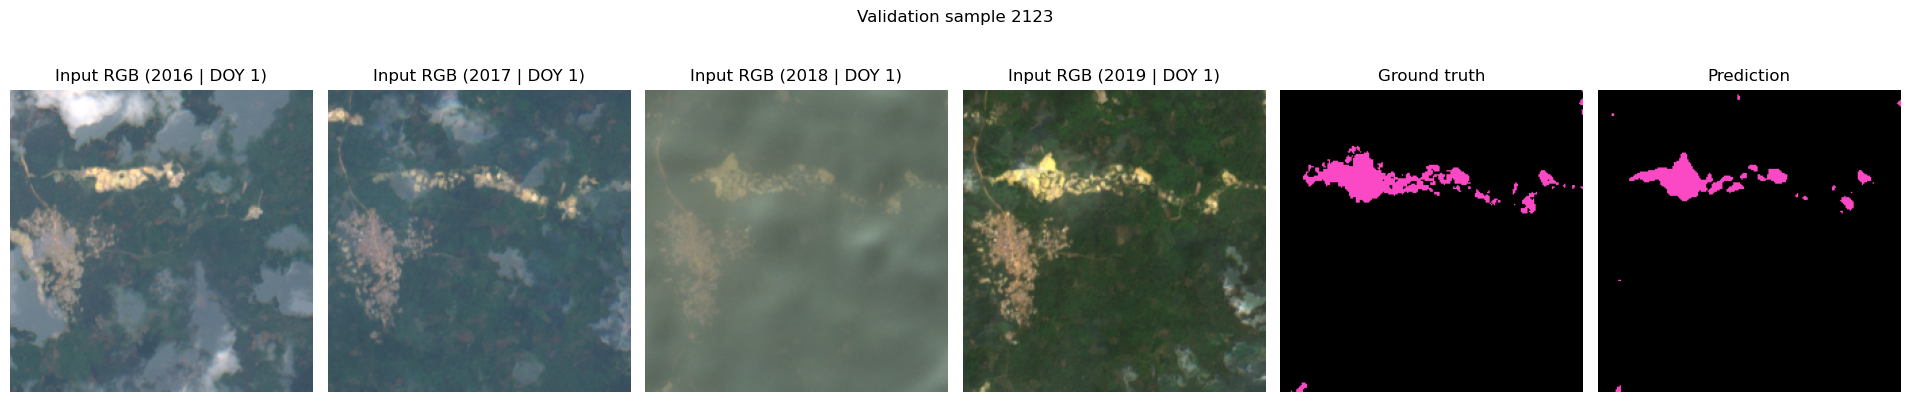

In [60]:
SAMPLE_INDEX = None  # Set to an integer, for example 1022, to revisit a sample.
#SAMPLE_INDEX = 1146 # Example index for visualization and saving.
prediction_sample = visualize_prediction(
    model,
    val_dataset,
    device=device,
    timesteps=TIMESTEPS,
    index=SAMPLE_INDEX,
)

In [ ]:
saved_prediction_sample = save_prediction_sample(prediction_sample)
saved_prediction_sample